# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** _____________POREDDY VEGSH REDDY_________  
**Register Number:** _____AP24110011455_________________  
**Date:** _____________22-08-2026_________  

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [4]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [5]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [7]:
# Write your answer here
# 1. Create a copy
tips_tip_missing = tips.copy()

# Make the random selection reproducible
np.random.seed(42)

# Select 5 random rows
missing_idx = np.random.choice(
    tips_tip_missing.index,
    size=5,
    replace=False
)

# Create missing values in the tip column
tips_tip_missing.loc[missing_idx, 'tip'] = np.nan

print("Missing values:", tips_tip_missing['tip'].isna().sum())

# 2. Calculate median tip for each time group
time_medians = tips_tip_missing.groupby('time')['tip'].transform('median')

# Fill missing tip values using the corresponding time median
tips_tip_filled = tips_tip_missing.copy()
tips_tip_filled['tip'] = tips_tip_missing['tip'].fillna(time_medians)

print("Remaining missing:", tips_tip_filled['tip'].isna().sum())

# Check the result
tips_tip_filled.loc[missing_idx, ['time', 'tip']]

Missing values: 5
Remaining missing: 0


,time,tip
24,Dinner,3.0
6,Dinner,3.0
153,Dinner,3.0
211,Dinner,3.0
198,Lunch,2.3


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*Filling missing values with a group-wise mean or median can be better because different groups may have different patterns or distributions. For example, in the tips dataset, lunch bills may generally be lower than dinner bills, so filling a missing tip with the median tip for its time group preserves the difference between lunch and dinner instead of using the same value for everyone.


## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [8]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [ ]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*label ,because there are only two catageries(binary)


In [9]:
# Write your answer here
tips_enc['time_encoded'] = tips_enc['time'].map({
    'Lunch': 0,
    'Dinner': 1
})

tips_enc[['time', 'time_encoded']].head()

,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*Label-encoding day as Thur=0, Fri=1, Sat=2, and Sun=3 would be misleading because it creates an artificial numerical order between the days. The model may assume that Sun is greater than Sat and Sat is greater than Fri, even though the days have no meaningful numerical relationship.


## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [11]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [12]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [13]:
# Write your answer here
print("Mean:", tips_enc['total_bill_standardized'].mean())
print("Standard deviation:", tips_enc['total_bill_standardized'].std())

Mean: -6.028875031263658e-17
Standard deviation: 1.0


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*Min-max scaling changes the values to a fixed range, usually 0 to 1. It is easy to understand and useful when we need a fixed range, but it is very sensitive to extreme outliers because the minimum and maximum determine the whole range. Standardization changes the data to have a mean of 0 and standard deviation of 1. It is also affected by outliers, but I would generally prefer standardization when the data is roughly normally distributed or when algorithms work better with centered data.


## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [14]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


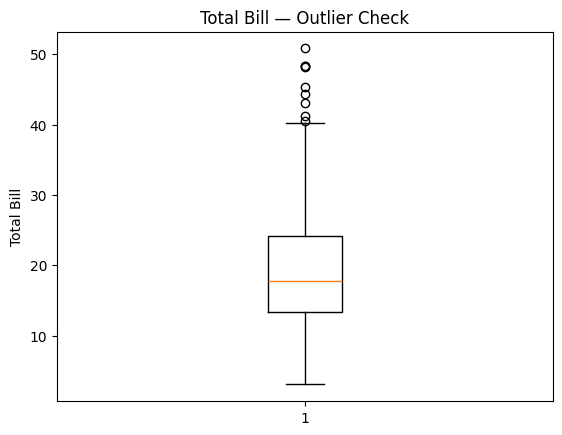

In [15]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


Q1: 2.00
Q3: 3.56
IQR: 1.56
Lower Bound: -0.34
Upper Bound: 5.91
Number of outliers: 9

Tip Outliers:
       tip  total_bill   day    time  size
23    7.58       39.42   Sat  Dinner     4
47    6.00       32.40   Sun  Dinner     4
59    6.73       48.27   Sat  Dinner     4
141   6.70       34.30  Thur   Lunch     6
170  10.00       50.81   Sat  Dinner     3
183   6.50       23.17   Sun  Dinner     4
212   9.00       48.33   Sat  Dinner     4
214   6.50       28.17   Sat  Dinner     3
239   5.92       29.03   Sat  Dinner     3

Original Tip Statistics:
count    244.000
mean       2.998
std        1.384
min        1.000
25%        2.000
50%        2.900
75%        3.562
max       10.000
Name: tip, dtype: float64

Capped Tip Statistics:
count    244.000
mean       2.950
std        1.226
min        1.000
25%        2.000
50%        2.900
75%        3.562
max        5.906
Name: tip, dtype: float64

Minimum after capping: 1.0
Maximum after capping: 5.90625


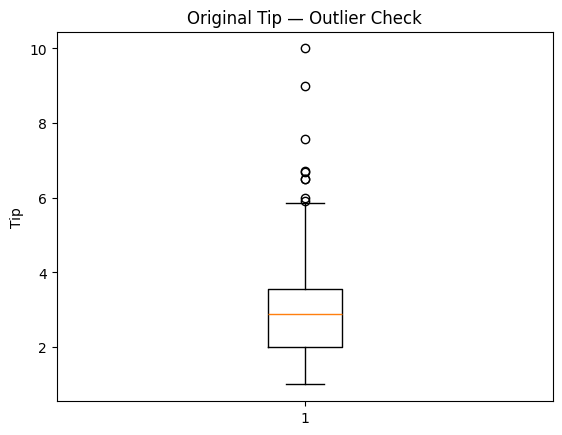

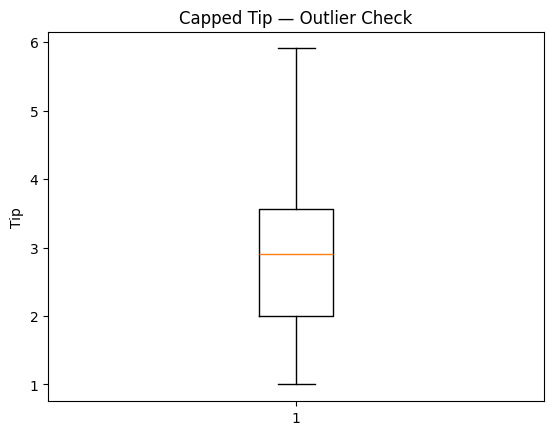

In [16]:
# Write your answer here
# Part 4: Student Practice
# Outlier Detection and Capping using IQR

# 1. Calculate Q1 and Q3
Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)

# 2. Calculate IQR
IQR = Q3 - Q1

# 3. Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Find outliers
tip_outliers = tips[
    (tips['tip'] < lower_bound) |
    (tips['tip'] > upper_bound)
]

# 5. Display the bounds and number of outliers
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(tip_outliers)}")

# 6. Display the detected outliers
print("\nTip Outliers:")
print(tip_outliers[['tip', 'total_bill', 'day', 'time', 'size']])

# 7. Create a copy of the original DataFrame
tips_capped = tips.copy()

# 8. Cap the outliers
tips_capped['tip'] = tips_capped['tip'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# 9. Compare original and capped values
print("\nOriginal Tip Statistics:")
print(tips['tip'].describe())

print("\nCapped Tip Statistics:")
print(tips_capped['tip'].describe())

# 10. Verify that no values are outside the bounds
print("\nMinimum after capping:", tips_capped['tip'].min())
print("Maximum after capping:", tips_capped['tip'].max())

# 11. Visualize original and capped data
plt.figure()
plt.boxplot(tips['tip'])
plt.title("Original Tip — Outlier Check")
plt.ylabel("Tip")
plt.show()

plt.figure()
plt.boxplot(tips_capped['tip'])
plt.title("Capped Tip — Outlier Check")
plt.ylabel("Tip")
plt.show()


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*Capping outliers can be preferable because it keeps the data rows and avoids losing potentially useful information, while limiting the effect of extreme values on the model. Dropping outliers is better when the extreme values are caused by data-entry errors, measurement errors, or are clearly invalid observations rather than genuine data.


## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.



In [17]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [18]:
# Write your answer here
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (170, 4)
Test shape: (74, 4)


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*It is important to keep the test data separate so the model can be evaluated on unseen data. If the model is trained on all the data, including the test set, it may memorize or learn from those examples, giving an unrealistically high performance and not showing how well it will perform on new data.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [24]:
from google.colab import files
uploaded = files.upload()


Saving cats.webp to cats.webp
Saving tiger.webp to tiger.webp
Saving red_deer.jpg to red_deer.jpg


In [25]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [26]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd

# List to store normalized image arrays
normalized_images = []

# List to store information about each image
results = []

# Process every uploaded image
for filename in filenames:

    # Open the image and convert it to NumPy array
    img_array = np.array(Image.open(filename))

    # Store original pixel range
    min_before = img_array.min()
    max_before = img_array.max()

    # Normalize pixel values from 0-255 to 0-1
    img_normalized = img_array / 255.0

    # Store normalized array in the list
    normalized_images.append(img_normalized)

    # Store normalization information
    results.append({
        'filename': filename,
        'min_pixel_before': min_before,
        'max_pixel_before': max_before,
        'min_pixel_after': img_normalized.min(),
        'max_pixel_after': img_normalized.max()
    })

# Create a DataFrame from the results
normalization_df = pd.DataFrame(results)

# Display the results
print(normalization_df)


       filename  min_pixel_before  max_pixel_before  min_pixel_after  \
0     cats.webp                 0               255              0.0   
1    tiger.webp                 0               255              0.0   
2  red_deer.jpg                 0               255              0.0   

   max_pixel_after  
0              1.0  
1              1.0  
2              1.0  


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [27]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (2160, 3840, 3)
Resized shape: (128, 128, 3)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [28]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd

# Target image size
target_size = (128, 128)

# Lists to store processed images and their information
processed_images = []
results = []

# Process every uploaded image
for filename in filenames:

    # Open the image
    img_pil = Image.open(filename)

    # Resize image to 128 x 128
    img_resized = img_pil.resize(target_size)

    # Convert resized image to NumPy array
    img_array = np.array(img_resized)

    # Normalize pixel values from 0-255 to 0-1
    img_normalized = img_array / 255.0

    # Store normalized image
    processed_images.append(img_normalized)

    # Store filename and resulting shape
    results.append({
        'filename': filename,
        'shape': img_normalized.shape
    })

# Create DataFrame
shape_df = pd.DataFrame(results)

# Display results
print(shape_df)

# Check whether all images have exactly the same shape
print("\nAll images have the same shape:",
      shape_df['shape'].nunique() == 1)

       filename          shape
0     cats.webp  (128, 128, 3)
1    tiger.webp  (128, 128, 3)
2  red_deer.jpg  (128, 128, 3)

All images have the same shape: True


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*Every image must have the same shape because the model expects a fixed number of input values for every sample. If images have different sizes, their arrays will have different dimensions, so they cannot be processed together in the same batch and the model will produce a shape or dimension mismatch error.


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [29]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [30]:
# Write your answer here
import re

raw_text = "Machine Learning is AMAZING!!! I studied 3 algorithms today."

# Convert to lowercase
cleaned = raw_text.lower()

# Remove punctuation
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)

# Tokenize into words
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: Machine Learning is AMAZING!!! I studied 3 algorithms today.
After: ['machine', 'learning', 'is', 'amazing', 'i', 'studied', '3', 'algorithms', 'today']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [31]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'3': 0, 'algorithms': 1, 'amazing': 2, 'i': 3, 'is': 4, 'learning': 5, 'machine': 6, 'studied': 7, 'today': 8}
Original tokens: ['machine', 'learning', 'is', 'amazing', 'i', 'studied', '3', 'algorithms', 'today']
Encoded as IDs:   [6, 5, 4, 2, 3, 7, 0, 1, 8]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [32]:
# Write your answer here
import re
import pandas as pd

# Your messy sentence
raw_text = "Machine Learning is AMAZING!!! I studied 3 algorithms today."

# Step 1: Clean the text
cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)

# Tokenize
tokens = cleaned.split()

print("Tokens:", tokens)

# Step 2: Build vocabulary
vocabulary = sorted(set(tokens))

# Create word-to-ID mapping
word_to_id = {
    word: idx
    for idx, word in enumerate(vocabulary)
}

print("\nWord to ID mapping:")
print(word_to_id)

# Encode the tokens into numeric IDs
encoded_tokens = [
    word_to_id[word]
    for word in tokens
]

print("\nOriginal tokens:")
print(tokens)

print("\nEncoded tokens:")
print(encoded_tokens)

# Step 3: Create DataFrame showing the complete mapping
mapping_df = pd.DataFrame(
    list(word_to_id.items()),
    columns=['word', 'id']
)

# Sort by ID
mapping_df = mapping_df.sort_values('id').reset_index(drop=True)

print("\nWord-to-ID DataFrame:")
print(mapping_df)

Tokens: ['machine', 'learning', 'is', 'amazing', 'i', 'studied', '3', 'algorithms', 'today']

Word to ID mapping:
{'3': 0, 'algorithms': 1, 'amazing': 2, 'i': 3, 'is': 4, 'learning': 5, 'machine': 6, 'studied': 7, 'today': 8}

Original tokens:
['machine', 'learning', 'is', 'amazing', 'i', 'studied', '3', 'algorithms', 'today']

Encoded tokens:
[6, 5, 4, 2, 3, 7, 0, 1, 8]

Word-to-ID DataFrame:
         word  id
0           3   0
1  algorithms   1
2     amazing   2
3           i   3
4          is   4
5    learning   5
6     machine   6
7     studied   7
8       today   8


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*Yes, the same problem applies to words. Assigning IDs such as machine = 1, learning = 2, and model = 3 creates an artificial numerical order, so a model might incorrectly think that model is greater than learning. The IDs are only labels and do not represent the meaning or similarity between words, so they should not be treated as meaningful numerical values.


# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
